# BC2410/BC2411 — Resume Shortlisting Optimisation
## Notebook 2: MILP Formulation, Baselines & Results

**Group Project — Prescriptive Analytics: From Data to Decisions**

---

### Design: Raw Signals → Per-Job Normalisation → MILP

Each matching signal (TF-IDF, BM25, skill overlap, etc.) has a different natural scale. TF-IDF cosine between a resume and a job description rarely exceeds 0.2, while BM25 can reach 1.0. Combining them directly produces misleadingly low scores.

**Fix**: We apply **per-job min-max normalisation** to each signal. For job *j*, each signal is scaled so the best-matching resume gets 1.0 and the worst gets 0.0. This is standard in information retrieval (per-query normalisation) and ensures that:
- All signals contribute equally when weights are equal
- Composite scores are interpretable on a 0–1 scale
- The quality floor constraint works as intended

## 1. Setup & Load Data

In [3]:
import json
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import gurobipy as gp
    from gurobipy import GRB
    HAS_GUROBI = True
except ImportError:
    HAS_GUROBI = False
    print("WARNING: Gurobi not installed. Only baselines will run.")

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("data")
OUT_DIR  = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# ── Load Notebook 1 outputs ──
pair_df   = pd.read_csv(DATA_DIR / "pair_features.csv")
resume_df = pd.read_csv(DATA_DIR / "resumes_milp_sample.csv")
job_df    = pd.read_csv(DATA_DIR / "jobs_milp_sample.csv")

for col in ["skill_set", "required_skills"]:
    for df in [resume_df, job_df]:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])
if "required_skill_weights" in job_df.columns:
    job_df["required_skill_weights"] = job_df["required_skill_weights"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else {})

print(f"Pairs: {len(pair_df):,}  |  Resumes: {len(resume_df)}  |  Jobs: {len(job_df)}")

Pairs: 45,000  |  Resumes: 500  |  Jobs: 90


## 2. Per-Job Signal Normalisation

### Why this matters

Raw signal ranges from Notebook 1:

| Signal | Mean | Max | Problem |
|--------|------|-----|---------|
| `tfidf_sim` | 0.033 | 0.21 | Very compressed — top candidate barely different from median |
| `bm25_sim` | 0.36 | 1.0 | Good range but dominates TF-IDF |
| `skill_jaccard` | 0.09 | 1.0 | Good range |
| `weighted_required_hit` | 0.18 | 1.0 | Good range |
| `exp_gap` | 0.58 | 9.0 | Years — not on 0–1 scale |
| `degree_gap` | 0.82 | 4.0 | Levels — not on 0–1 scale |

After per-job min-max normalisation, **every signal is on [0, 1] for each job**, so:
- Weights are directly interpretable (0.25 means "this signal is 25% of the total")
- The best resume for a given job always scores 1.0 on each signal
- Penalties are also normalised to [0, 1]

In [6]:
# ── Per-job min-max normalisation ──
SIGNALS_TO_NORMALISE = {
    # Positive signals (higher = better match)
    "tfidf_sim": "pos",
    "bm25_sim": "pos",
    "skill_overlap_jaccard": "pos",
    "weighted_required_hit": "pos",
    # Negative signals (higher = worse, will be inverted to "lower gap = better")
    "exp_gap": "neg",
    "degree_gap": "neg",
    "length_penalty": "neg",
}

norm_df = pair_df.copy()

for signal, direction in SIGNALS_TO_NORMALISE.items():
    col_norm = f"{signal}_norm"
    
    # Min-max per job
    grouped = norm_df.groupby("job_id")[signal]
    mins = grouped.transform("min")
    maxs = grouped.transform("max")
    rng = maxs - mins
    
    # Normalise to [0, 1]; if range is 0, set to 0.5
    norm_df[col_norm] = np.where(rng > 1e-9, (norm_df[signal] - mins) / rng, 0.5)
    
    # For negative signals, invert so 0 gap → 1.0 (good) and max gap → 0.0 (bad)
    if direction == "neg":
        norm_df[col_norm] = 1.0 - norm_df[col_norm]

# Verify normalisation
print("Per-job normalised signal ranges:")
for signal in SIGNALS_TO_NORMALISE:
    col = f"{signal}_norm"
    print(f"  {col:35s}  mean={norm_df[col].mean():.3f}  min={norm_df[col].min():.3f}  max={norm_df[col].max():.3f}")

Per-job normalised signal ranges:
  tfidf_sim_norm                       mean=0.324  min=0.000  max=1.000
  bm25_sim_norm                        mean=0.362  min=0.000  max=1.000
  skill_overlap_jaccard_norm           mean=0.205  min=0.000  max=1.000
  weighted_required_hit_norm           mean=0.208  min=0.000  max=1.000
  exp_gap_norm                         mean=0.820  min=0.000  max=1.000
  degree_gap_norm                      mean=0.658  min=0.000  max=1.000
  length_penalty_norm                  mean=0.952  min=0.000  max=1.000


## 3. MILP Configuration

### 3.1 Structural Parameters

In [8]:
K_SHORTLIST         = 5
MAX_CANDIDATE_JOBS  = 2
REVIEW_BUDGET_MIN   = 65.0    # calibrated from NB1: median ~10 min/resume × 5 + buffer
MAX_CLUSTER_PER_JOB = 1
MIN_AVG_SCORE_FLOOR = 0.40    # now meaningful on the 0–1 normalised scale
GUROBI_TIME_LIMIT   = 600
GUROBI_MIP_GAP      = 0.001   # stop when within 0.1% of optimal

print(f"Budget: {REVIEW_BUDGET_MIN} min  |  Quality floor: {MIN_AVG_SCORE_FLOOR}  |  Solver limit: {GUROBI_TIME_LIMIT}s")

Budget: 65.0 min  |  Quality floor: 0.4  |  Solver limit: 600s


### 3.2 Objective Coefficients

Now that all signals are on [0, 1], these weights are directly interpretable as **relative importance**.

In [10]:
DEFAULT_CONFIG = {
    "w_tfidf":    0.15,   # lexical similarity
    "w_bm25":     0.15,   # term-frequency relevance
    "w_skill":    0.25,   # skill set overlap
    "w_coverage": 0.20,   # scarcity-weighted required skill hits
    "w_exp":      0.10,   # experience match (inverted gap)
    "w_deg":      0.05,   # degree match (inverted gap)
    "w_length":   0.05,   # resume length match (inverted penalty)
    "w_skill_cov": 0.12,  # shortlist-level coverage bonus
    "w_underfill": 0.35,  # underfill penalty per slot
    "w_quality":   0.25,  # quality shortfall penalty
}

# Verify positive weights sum to ~1
pos_sum = sum(DEFAULT_CONFIG[k] for k in ["w_tfidf","w_bm25","w_skill","w_coverage","w_exp","w_deg","w_length"])
print(f"Per-pair signal weights sum: {pos_sum:.2f} (should be ~1.0)")
for k, v in DEFAULT_CONFIG.items():
    print(f"  {k:16s} = {v:.2f}")

Per-pair signal weights sum: 0.95 (should be ~1.0)
  w_tfidf          = 0.15
  w_bm25           = 0.15
  w_skill          = 0.25
  w_coverage       = 0.20
  w_exp            = 0.10
  w_deg            = 0.05
  w_length         = 0.05
  w_skill_cov      = 0.12
  w_underfill      = 0.35
  w_quality        = 0.25


## 4. Build Lookup Tables

In [12]:
# ── Normalised pair-level lookups ──
n_tfidf = {}; n_bm25 = {}; n_skill = {}; n_cov = {}
n_exp = {}; n_deg = {}; n_length = {}

for _, row in norm_df.iterrows():
    key = (int(row["resume_id"]), int(row["job_id"]))
    n_tfidf[key]  = float(row["tfidf_sim_norm"])
    n_bm25[key]   = float(row["bm25_sim_norm"])
    n_skill[key]  = float(row["skill_overlap_jaccard_norm"])
    n_cov[key]    = float(row["weighted_required_hit_norm"])
    n_exp[key]    = float(row["exp_gap_norm"])        # already inverted: 1 = no gap
    n_deg[key]    = float(row["degree_gap_norm"])      # already inverted
    n_length[key] = float(row["length_penalty_norm"])  # already inverted

# ── Resume-level ──
review_time = {}; cluster_of = {}
for _, r in resume_df.iterrows():
    rid = int(r["resume_id"])
    review_time[rid] = float(r["review_minutes_capped"])
    cluster_of[rid]  = int(r["redundancy_cluster"])

# ── Job-level ──
job_req_skills = {}; skill_weight = {}; skill_has = {}
for _, row in job_df.iterrows():
    j = int(row["job_id"])
    req = row["required_skills"]
    weights = row["required_skill_weights"]
    job_req_skills[j] = set(req)
    for s in req:
        skill_weight[(j, s)] = float(weights.get(s, 1.0))

for _, row in pair_df.iterrows():
    i, j = int(row["resume_id"]), int(row["job_id"])
    if j in job_req_skills:
        r_skills = set(resume_df.loc[resume_df["resume_id"] == i, "skill_set"].iloc[0])
        for s in job_req_skills[j]:
            skill_has[(i, j, s)] = 1 if s in r_skills else 0

cluster_members = {}
for rid, cid in cluster_of.items():
    cluster_members.setdefault(cid, []).append(rid)

ALL_RESUMES = sorted(resume_df["resume_id"].unique())
ALL_JOBS    = sorted(job_df["job_id"].unique())
ALL_PAIRS   = list(n_tfidf.keys())

print(f"Pairs: {len(ALL_PAIRS):,}  |  Clusters: {len(cluster_members)} ({sum(1 for v in cluster_members.values() if len(v)>1)} multi-resume)")

Pairs: 45,000  |  Clusters: 479 (13 multi-resume)


## 5. MILP Solver

### 5.1 Core Solver Function

All signals enter the objective **already normalised to [0, 1]**, so positive terms are rewards and all coefficients are directly interpretable.

In [14]:
def pair_quality(i, j, w):
    """Compute normalised pair quality score (0–1 scale)."""
    return (w["w_tfidf"]  * n_tfidf[(i,j)]
          + w["w_bm25"]   * n_bm25[(i,j)]
          + w["w_skill"]  * n_skill[(i,j)]
          + w["w_coverage"]* n_cov[(i,j)]
          + w["w_exp"]    * n_exp[(i,j)]
          + w["w_deg"]    * n_deg[(i,j)]
          + w["w_length"] * n_length[(i,j)])


def solve_milp(config: dict, verbose: bool = True,
               budget: float = None, floor: float = None) -> dict:
    """
    Build and solve the MILP.
    All per-pair signals are normalised to [0,1], so the objective
    and quality floor operate on the same interpretable scale.
    """
    if not HAS_GUROBI:
        return {"selected": [], "obj_val": 0, "status": "no_gurobi",
                "solve_time": 0, "config": config, "gap": None}

    w = config
    B = budget or REVIEW_BUDGET_MIN
    F = floor or MIN_AVG_SCORE_FLOOR
    t0 = time.perf_counter()

    m = gp.Model("ResumeShortlisting")
    m.Params.OutputFlag = 1 if verbose else 0
    m.Params.TimeLimit = GUROBI_TIME_LIMIT
    m.Params.MIPGap = GUROBI_MIP_GAP

    # ── Variables ──
    x = {(i,j): m.addVar(vtype=GRB.BINARY) for (i,j) in ALL_PAIRS}
    u = {j: m.addVar(lb=0, ub=K_SHORTLIST) for j in ALL_JOBS}
    y = {}
    for j in ALL_JOBS:
        for s in job_req_skills.get(j, []):
            y[j, s] = m.addVar(vtype=GRB.BINARY)
    q = {j: m.addVar(lb=0) for j in ALL_JOBS}
    m.update()

    # ── Objective ──
    obj = gp.LinExpr()

    # Per-pair quality (all signals normalised, all positive)
    for (i, j), var in x.items():
        obj += pair_quality(i, j, w) * var

    # Shortlist-level skill coverage bonus
    for (j, s), var in y.items():
        obj += w["w_skill_cov"] * skill_weight.get((j, s), 1.0) * var

    # Penalties
    for j in ALL_JOBS:
        obj -= w["w_underfill"] * u[j]
        obj -= w["w_quality"]   * q[j]

    m.setObjective(obj, GRB.MAXIMIZE)

    # ── C1: Shortlist size ──
    for j in ALL_JOBS:
        m.addConstr(gp.quicksum(x[i,j] for i in ALL_RESUMES if (i,j) in x) + u[j] == K_SHORTLIST)

    # ── C2: Review time budget ──
    for j in ALL_JOBS:
        m.addConstr(gp.quicksum(review_time[i] * x[i,j] for i in ALL_RESUMES if (i,j) in x) <= B)

    # ── C3: Candidate exposure cap ──
    for i in ALL_RESUMES:
        m.addConstr(gp.quicksum(x[i,j] for j in ALL_JOBS if (i,j) in x) <= MAX_CANDIDATE_JOBS)

    # ── C4: Skill coverage linking ──
    for j in ALL_JOBS:
        for s in job_req_skills.get(j, []):
            if (j, s) in y:
                m.addConstr(y[j,s] <= gp.quicksum(
                    skill_has.get((i,j,s), 0) * x[i,j] for i in ALL_RESUMES if (i,j) in x))

    # ── C5: Minimum average quality (soft, on normalised 0–1 scale) ──
    for j in ALL_JOBS:
        m.addConstr(
            gp.quicksum(pair_quality(i, j, w) * x[i,j] for i in ALL_RESUMES if (i,j) in x) + q[j]
            >= F * (K_SHORTLIST - u[j])
        )

    # ── C6: Anti-redundancy ──
    for j in ALL_JOBS:
        for cid, members in cluster_members.items():
            if len(members) > 1:
                eligible = [i for i in members if (i,j) in x]
                if len(eligible) > 1:
                    m.addConstr(gp.quicksum(x[i,j] for i in eligible) <= MAX_CLUSTER_PER_JOB)

    m.optimize()
    solve_time = time.perf_counter() - t0

    if m.Status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and m.SolCount > 0:
        selected = [(i,j) for (i,j), var in x.items() if var.X > 0.5]
        return {"selected": selected, "obj_val": m.ObjVal, "status": m.Status,
                "solve_time": solve_time, "config": config,
                "gap": m.MIPGap if hasattr(m, "MIPGap") else None}
    return {"selected": [], "obj_val": 0, "status": m.Status,
            "solve_time": solve_time, "config": config, "gap": None}

### 5.2 Evaluation Function

In [16]:
def evaluate(selected_pairs, label="Method", config=None):
    """Compute operational metrics using normalised signals."""
    w = config or DEFAULT_CONFIG
    sel = pd.DataFrame(selected_pairs, columns=["resume_id", "job_id"])
    sel = sel.merge(norm_df, on=["resume_id", "job_id"], how="left")

    job_rows = []
    for j in ALL_JOBS:
        js = sel[sel["job_id"] == j]
        n = len(js)

        # Per-pair normalised quality score
        if n > 0:
            scores = []
            for _, row in js.iterrows():
                key = (int(row["resume_id"]), j)
                scores.append(pair_quality(key[0], key[1], w))
            mean_score = np.mean(scores)
        else:
            mean_score = 0.0

        # Skill coverage
        req = set(job_df.loc[job_df["job_id"] == j, "required_skills"].iloc[0])
        covered = set()
        for _, row in js.iterrows():
            r_sk = set(resume_df.loc[resume_df["resume_id"] == int(row["resume_id"]), "skill_set"].iloc[0])
            covered |= (r_sk & req)
        cov = len(covered) / max(len(req), 1)
        t_min = js["review_minutes_capped"].sum() if n > 0 else 0.0

        job_rows.append({"n": n, "score": mean_score, "coverage": cov,
                         "time": t_min, "cov_per_min": cov / max(t_min, 0.01),
                         "underfilled": int(n < K_SHORTLIST)})

    jm = pd.DataFrame(job_rows)
    unique = sel["resume_id"].nunique()

    return {
        "method": label, "total_selected": len(sel),
        "mean_match_score": jm["score"].mean(),
        "mean_coverage": jm["coverage"].mean(),
        "mean_cov_per_min": jm["cov_per_min"].mean(),
        "mean_review_min": jm["time"].mean(),
        "novelty_ratio": unique / max(len(sel), 1),
        "underfilled_jobs": int(jm["underfilled"].sum()),
    }

### 5.3 Run Default MILP

In [18]:
print("Solving MILP with default config …")
milp_result = solve_milp(DEFAULT_CONFIG, verbose=True)
print(f"\nSelected: {len(milp_result['selected'])} | Obj: {milp_result['obj_val']:.2f} | "
      f"Gap: {milp_result.get('gap','N/A')} | Time: {milp_result['solve_time']:.1f}s")

Solving MILP with default config …
Set parameter Username
Set parameter LicenseID to value 2769976
Academic license - for non-commercial use only - expires 2027-01-26
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.001
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 7 255H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.001

Optimize a model with 2326 rows, 45566 columns and 220785 nonzeros (Max)
Model fingerprint: 0x906d07e4
Model has 45566 linear objective coefficients
Variable types: 180 continuous, 45386 integer (45386 binary)
Coefficient statistics:
  Matrix range     [6e-02, 3e+01]
  Objective range  [6e-02, 9e-01]
  Bounds range     [1e+00, 5e+00]
  RHS range        [1e+00, 7e+01]

Found heuristic solution: objective 181.3241437
Presolve rem

## 6. Automated Coefficient Sweep

In [20]:
SWEEP_CONFIGS = {
    "default": (DEFAULT_CONFIG, REVIEW_BUDGET_MIN, MIN_AVG_SCORE_FLOOR),

    "coverage_focus": ({
        **DEFAULT_CONFIG, "w_skill": 0.30, "w_coverage": 0.25, "w_skill_cov": 0.18,
        "w_tfidf": 0.10, "w_bm25": 0.10,
    }, REVIEW_BUDGET_MIN, 0.35),

    "score_focus": ({
        **DEFAULT_CONFIG, "w_tfidf": 0.22, "w_bm25": 0.20, "w_skill": 0.20,
        "w_coverage": 0.15, "w_skill_cov": 0.06,
    }, REVIEW_BUDGET_MIN, 0.45),

    "exp_strict": ({
        **DEFAULT_CONFIG, "w_exp": 0.20, "w_deg": 0.10, "w_skill": 0.20, "w_coverage": 0.15,
    }, REVIEW_BUDGET_MIN, 0.40),

    "tight_budget": (DEFAULT_CONFIG, 45.0, 0.35),

    "balanced": ({
        "w_tfidf": 0.15, "w_bm25": 0.15, "w_skill": 0.20, "w_coverage": 0.18,
        "w_exp": 0.12, "w_deg": 0.06, "w_length": 0.04,
        "w_skill_cov": 0.10, "w_underfill": 0.30, "w_quality": 0.22,
    }, REVIEW_BUDGET_MIN, 0.38),
}

sweep_rows = []
for name, (cfg, budget, floor) in SWEEP_CONFIGS.items():
    print(f"Running: {name} (budget={budget}, floor={floor}) …")
    result = solve_milp(cfg, verbose=False, budget=budget, floor=floor)
    metrics = evaluate(result["selected"], label=name, config=cfg)
    underfill_rate = metrics["underfilled_jobs"] / len(ALL_JOBS)
    meta = metrics["mean_match_score"] * metrics["mean_coverage"] * (1 - underfill_rate)
    sweep_rows.append({
        "config": name, "budget": budget, "floor": floor,
        **metrics, "obj_val": result["obj_val"],
        "solve_time": result["solve_time"], "gap": result.get("gap"),
        "meta_score": meta,
    })

sweep_df = pd.DataFrame(sweep_rows).sort_values("meta_score", ascending=False)
print("\n" + "═"*80)
display(sweep_df[["config","mean_match_score","mean_coverage","novelty_ratio",
                  "underfilled_jobs","mean_review_min","meta_score"]])

best_name = sweep_df.iloc[0]["config"]
BEST_CONFIG, BEST_BUDGET, BEST_FLOOR = SWEEP_CONFIGS[best_name]
print(f"\nBest: {best_name} (meta={sweep_df.iloc[0]['meta_score']:.4f})")

Running: default (budget=65.0, floor=0.4) …
Running: coverage_focus (budget=65.0, floor=0.35) …
Running: score_focus (budget=65.0, floor=0.45) …
Running: exp_strict (budget=65.0, floor=0.4) …
Running: tight_budget (budget=45.0, floor=0.35) …
Running: balanced (budget=65.0, floor=0.38) …

════════════════════════════════════════════════════════════════════════════════


,config,mean_match_score,mean_coverage,novelty_ratio,underfilled_jobs,mean_review_min,meta_score
3,exp_strict,0.7397,0.9578,0.6067,0,61.4241,0.7084
1,coverage_focus,0.6881,0.9578,0.6244,0,59.5175,0.6591
2,score_focus,0.6895,0.9556,0.6133,0,61.8506,0.6589
0,default,0.6790,0.9578,0.6178,0,60.8648,0.6503
5,balanced,0.6466,0.9578,0.6267,0,61.3397,0.6193
4,tight_budget,0.6346,0.9511,0.5956,0,43.6905,0.6036



Best: exp_strict (meta=0.7084)


## 7. Baselines

In [22]:
def greedy_baseline(pair_df_norm, config=None, k=K_SHORTLIST,
                    budget=REVIEW_BUDGET_MIN, max_exposure=MAX_CANDIDATE_JOBS):
    """Greedy shortlisting using normalised scores, with constraints."""
    w = config or DEFAULT_CONFIG

    # Pre-compute normalised scores
    scores = {}
    for (i,j) in ALL_PAIRS:
        scores[(i,j)] = pair_quality(i, j, w)

    exposure = Counter()
    selected = []

    for j in sorted(set(jj for (_,jj) in ALL_PAIRS)):
        candidates = [(scores[(i,j)], i) for (ii,jj) in ALL_PAIRS if jj == j for i in [ii]]
        # Deduplicate and sort
        seen = set()
        unique_cands = []
        for s, i in sorted(candidates, reverse=True):
            if i not in seen:
                unique_cands.append((s, i))
                seen.add(i)

        shortlist, t_used, clusters_used = [], 0.0, set()
        for s, i in unique_cands:
            if len(shortlist) >= k: break
            t = review_time[i]
            c = cluster_of[i]
            if exposure[i] >= max_exposure or t_used + t > budget or c in clusters_used:
                continue
            shortlist.append((i, j)); exposure[i] += 1; t_used += t; clusters_used.add(c)
        selected.extend(shortlist)
    return selected

greedy_selected = greedy_baseline(norm_df, DEFAULT_CONFIG, budget=BEST_BUDGET)
print(f"Greedy: {len(greedy_selected)} pairs")

Greedy: 383 pairs


In [23]:
def scoreonly_baseline(config=None, k=K_SHORTLIST):
    """Top-k by score per job, no constraints."""
    w = config or DEFAULT_CONFIG
    selected = []
    for j in ALL_JOBS:
        cands = [(pair_quality(i, j, w), i) for i in ALL_RESUMES if (i,j) in n_tfidf]
        cands.sort(reverse=True)
        selected.extend([(i, j) for _, i in cands[:k]])
    return selected

scoreonly_selected = scoreonly_baseline(DEFAULT_CONFIG)
print(f"ScoreOnly: {len(scoreonly_selected)} pairs")

ScoreOnly: 450 pairs


## 8. Results Comparison

### 8.1 Metric Table

In [25]:
print(f"Best config: '{best_name}' | Budget: {BEST_BUDGET} | Floor: {BEST_FLOOR}")
best_milp = solve_milp(BEST_CONFIG, verbose=False, budget=BEST_BUDGET, floor=BEST_FLOOR)

greedy_best = greedy_baseline(norm_df, BEST_CONFIG, budget=BEST_BUDGET)
scoreonly_best = scoreonly_baseline(BEST_CONFIG)

results = [
    evaluate(best_milp["selected"], "MILP (best)", BEST_CONFIG),
    evaluate(greedy_best, "Greedy", BEST_CONFIG),
    evaluate(scoreonly_best, "ScoreOnly", BEST_CONFIG),
]

comparison = pd.DataFrame(results).set_index("method")
print("\n" + "═"*80)
print("FINAL METHOD COMPARISON")
print("═"*80)
display(comparison.T)

Best config: 'exp_strict' | Budget: 65.0 | Floor: 0.4

════════════════════════════════════════════════════════════════════════════════
FINAL METHOD COMPARISON
════════════════════════════════════════════════════════════════════════════════


method,MILP (best),Greedy,ScoreOnly
total_selected,450.0000,370.0000,450.0000
mean_match_score,0.7397,0.7538,0.7943
mean_coverage,0.9578,0.9144,0.9328
mean_cov_per_min,0.0158,0.0153,0.0101
mean_review_min,61.4241,61.2030,100.2138
novelty_ratio,0.6067,0.6189,0.3956
underfilled_jobs,0.0000,55.0000,0.0000


### 8.2 Visual Comparison

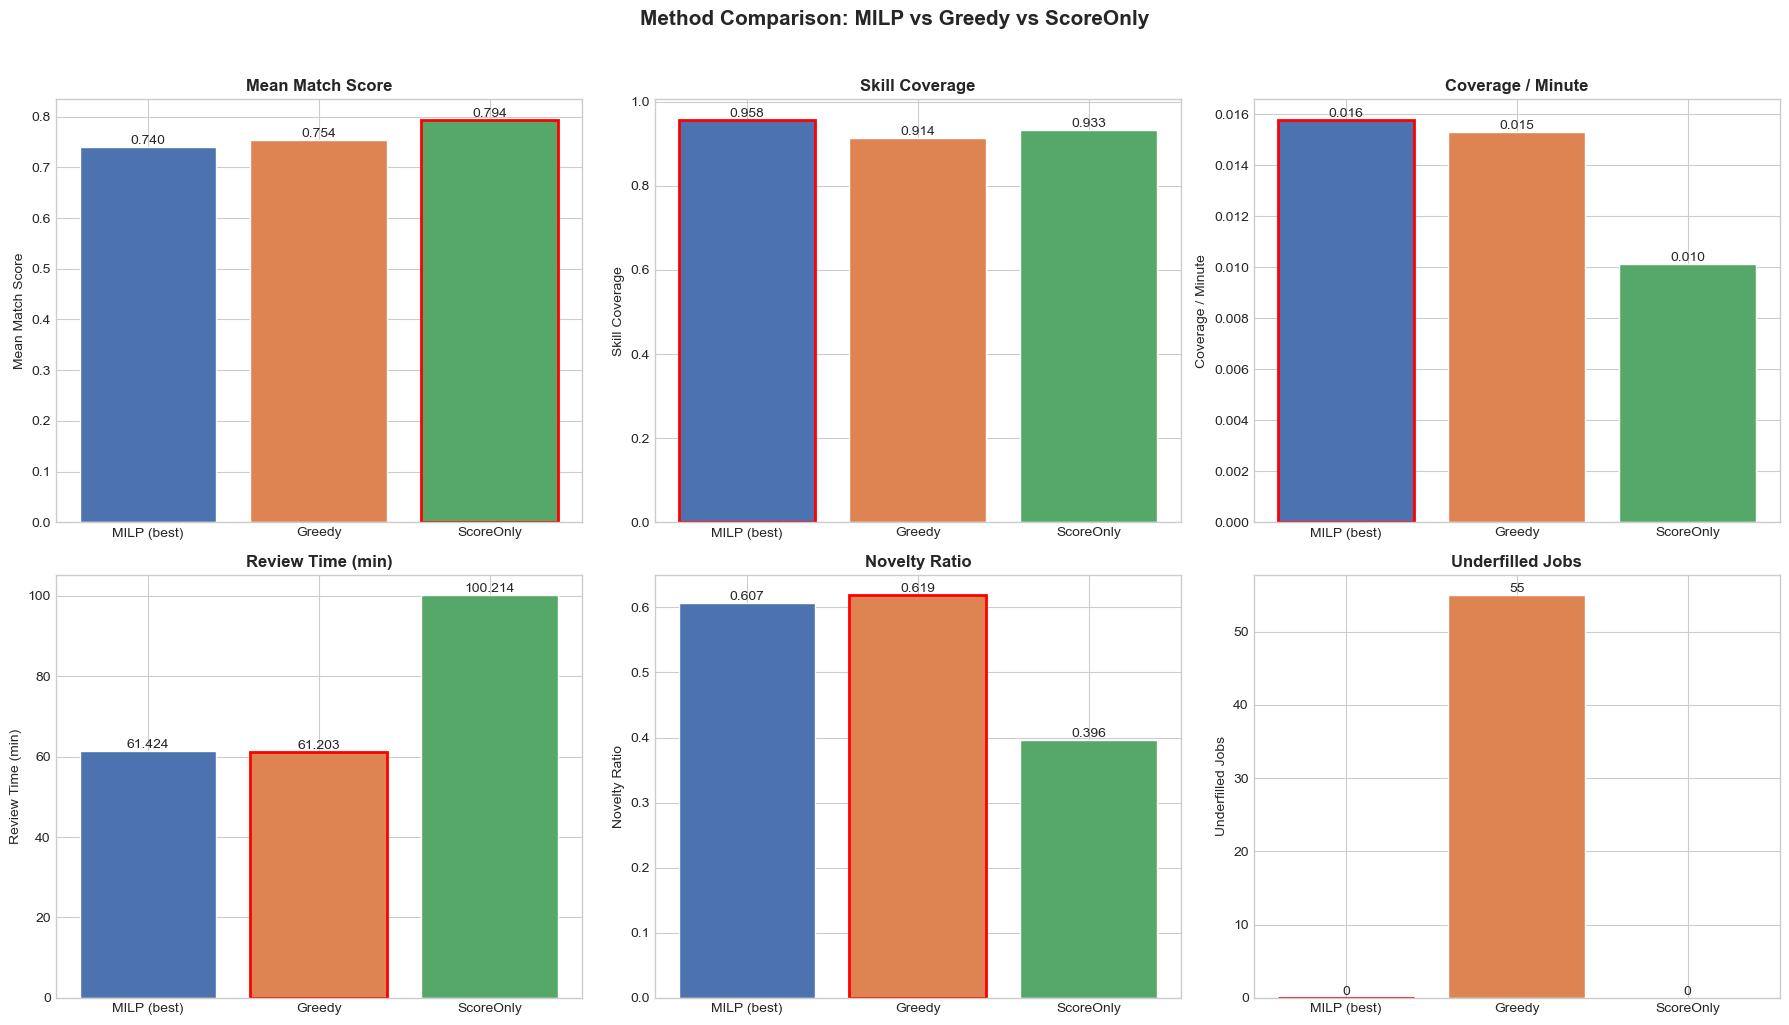

In [27]:
metrics_to_plot = [
    ("mean_match_score", "Mean Match Score", True),
    ("mean_coverage", "Skill Coverage", True),
    ("mean_cov_per_min", "Coverage / Minute", True),
    ("mean_review_min", "Review Time (min)", False),
    ("novelty_ratio", "Novelty Ratio", True),
    ("underfilled_jobs", "Underfilled Jobs", False),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = {"MILP (best)": "#4C72B0", "Greedy": "#DD8452", "ScoreOnly": "#55A868"}

for ax, (metric, title, higher_better) in zip(axes.flat, metrics_to_plot):
    methods = comparison.index.tolist()
    values = comparison[metric].tolist()
    bars = ax.bar(methods, values, color=[colors.get(m, "gray") for m in methods], edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold"); ax.set_ylabel(title)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:.3f}" if isinstance(val, float) else str(val),
                ha="center", va="bottom", fontsize=10)
    best_idx = values.index(max(values)) if higher_better else values.index(min(values))
    bars[best_idx].set_edgecolor("red"); bars[best_idx].set_linewidth(2)

fig.suptitle("Method Comparison: MILP vs Greedy vs ScoreOnly", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig(OUT_DIR / "01_method_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

### 8.3 Sweep Results

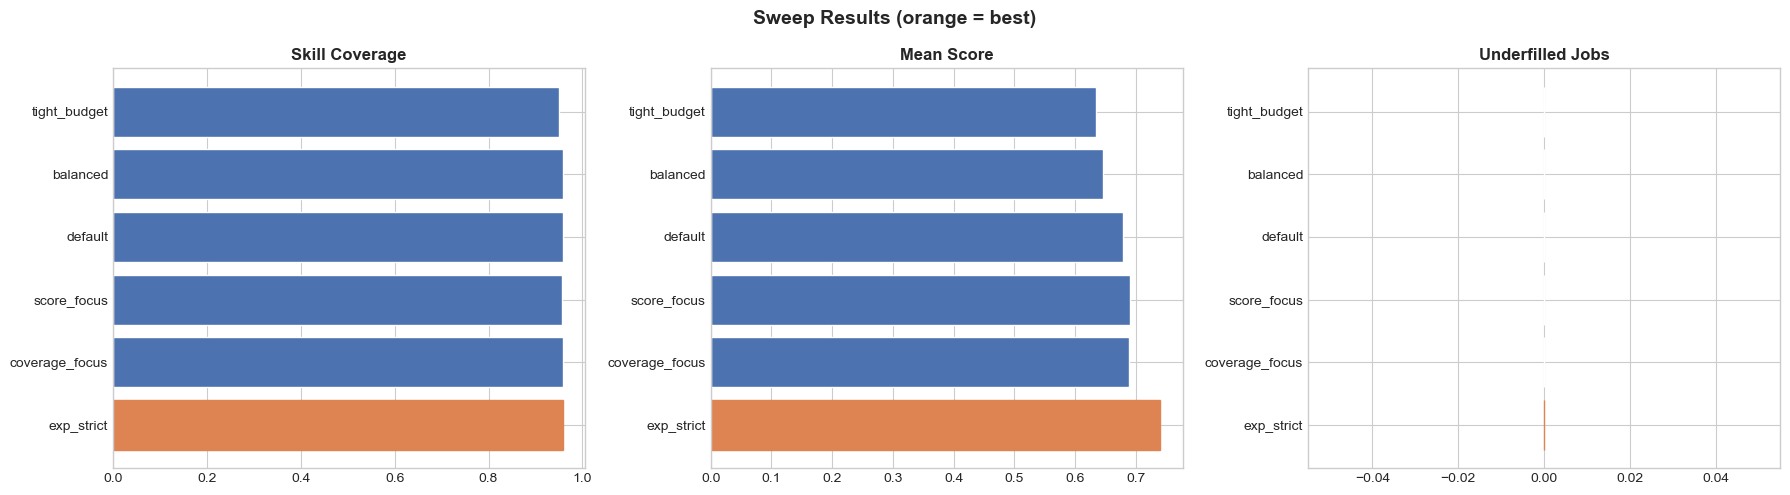

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sp = sweep_df.sort_values("meta_score", ascending=False)

for ax, (metric, title) in zip(axes, [
    ("mean_coverage", "Skill Coverage"), ("mean_match_score", "Mean Score"),
    ("underfilled_jobs", "Underfilled Jobs")
]):
    bars = ax.barh(sp["config"], sp[metric], color="#4C72B0", edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold")
    best_idx = list(sp["config"]).index(best_name)
    bars[best_idx].set_color("#DD8452")

fig.suptitle("Sweep Results (orange = best)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "02_sweep_results.png", dpi=150, bbox_inches="tight"); plt.show()

### 8.4 Per-Job Breakdown

In [31]:
if best_milp["selected"]:
    sel_df = pd.DataFrame(best_milp["selected"], columns=["resume_id", "job_id"])
    sel_df = sel_df.merge(pair_df, on=["resume_id", "job_id"], how="left")

    job_summary = []
    for j in ALL_JOBS:
        js = sel_df[sel_df["job_id"] == j]
        title = job_df.loc[job_df["job_id"] == j, "job_title"].iloc[0]
        req = set(job_df.loc[job_df["job_id"] == j, "required_skills"].iloc[0])
        covered = set()
        for _, row in js.iterrows():
            r_sk = set(resume_df.loc[resume_df["resume_id"] == int(row["resume_id"]), "skill_set"].iloc[0])
            covered |= (r_sk & req)

        scores = [pair_quality(int(row["resume_id"]), j, BEST_CONFIG) for _, row in js.iterrows()] if len(js) > 0 else [0]

        job_summary.append({
            "job_id": j, "title": title, "selected": len(js),
            "mean_score": np.mean(scores),
            "coverage": len(covered) / max(len(req), 1),
            "review_min": js["review_minutes_capped"].sum() if len(js) > 0 else 0,
        })

    jsdf = pd.DataFrame(job_summary)
    print(f"Full shortlists: {(jsdf['selected'] == K_SHORTLIST).sum()} / {len(ALL_JOBS)}")
    print(f"Underfilled:     {(jsdf['selected'] < K_SHORTLIST).sum()}")
    print(f"Mean score:      {jsdf['mean_score'].mean():.3f}")
    print(f"Mean coverage:   {jsdf['coverage'].mean():.3f}")
    display(jsdf.head(15))

Full shortlists: 90 / 90
Underfilled:     0
Mean score:      0.740
Mean coverage:   0.958


,job_id,title,selected,mean_score,coverage,review_min
0,0,Backend Developer,5,0.7543,1.0000,62.0195
1,1,Backend Developer,5,0.7563,1.0000,61.5940
2,2,Backend Developer,5,0.7675,1.0000,63.5375
3,3,Backend Developer,5,0.7090,1.0000,64.9405
4,4,Backend Developer,5,0.7376,1.0000,64.6185
5,5,Backend Developer,5,0.6368,1.0000,64.3310
6,6,Database Administrator,5,0.8121,1.0000,64.5265
7,7,Database Administrator,5,0.6979,1.0000,63.2730
8,8,Database Administrator,5,0.8558,1.0000,63.5605
9,9,Database Administrator,5,0.7973,1.0000,62.6175


## 9. Save Results

In [33]:
comparison.to_csv(OUT_DIR / "method_comparison.csv")
sweep_df.to_csv(OUT_DIR / "sweep_results.csv", index=False)

if best_milp["selected"]:
    pd.DataFrame(best_milp["selected"], columns=["resume_id","job_id"]).to_csv(
        OUT_DIR / "milp_best_selected.csv", index=False)
pd.DataFrame(greedy_best, columns=["resume_id","job_id"]).to_csv(OUT_DIR / "greedy_selected.csv", index=False)
pd.DataFrame(scoreonly_best, columns=["resume_id","job_id"]).to_csv(OUT_DIR / "scoreonly_selected.csv", index=False)

with open(OUT_DIR / "best_config.json", "w") as f:
    json.dump({"name": best_name, "config": BEST_CONFIG,
               "budget": BEST_BUDGET, "floor": BEST_FLOOR}, f, indent=2)

print("Saved:"); [print(f"  {f.name}") for f in sorted(OUT_DIR.glob("*"))]

Saved:
  01_extraction_coverage.png
  01_method_comparison.png
  02_job_title_distribution.png
  02_sweep_results.png
  03_word_count_distributions.png
  04_skills_analysis.png
  05_experience_education.png
  06_redundancy_sweep.png
  07_redundancy_clusters.png
  best_config.json
  greedy_selected.csv
  method_comparison.csv
  milp_best_selected.csv
  scoreonly_selected.csv
  sweep_results.csv


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

## 10. Parameter Summary

### Why Per-Job Normalisation Fixes the Score Problem

| Before (raw) | After (normalised) |
|---|---|
| TF-IDF: 0–0.21 | TF-IDF_norm: 0–1.0 per job |
| BM25: 0–1.0 | BM25_norm: 0–1.0 per job |
| Skill Jaccard: 0–1.0 | Skill_norm: 0–1.0 per job |
| exp_gap: 0–9 years | exp_match_norm: 0–1.0 (inverted) |
| degree_gap: 0–4 levels | deg_match_norm: 0–1.0 (inverted) |

After normalisation, a composite score of 0.80 means *"this candidate is at the 80th percentile across all signals for this job"* — directly interpretable.

### Structural Constraints
| Parameter | Value | Justification |
|-----------|-------|---------------|
| `K_SHORTLIST` | 5 | Standard tech hiring shortlist |
| `MAX_CANDIDATE_JOBS` | 2 | Prevents monopolisation |
| `REVIEW_BUDGET_MIN` | 65 | ~13 min/resume × 5; median from NB1 |
| `MIN_AVG_SCORE_FLOOR` | 0.40 | On normalised 0–1 scale |
| `GUROBI_MIP_GAP` | 0.1% | Early termination when near-optimal |

---

**Next → Notebook 3**: Sensitivity analysis on budget, shortlist size, exposure cap.